In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from uqct.utils import load_runs_dense, find_experiment_dense as find_experiment
from uqct.vis import style
from uqct.vis.style import get_model_colors, get_style, ICML_COLUMN_HEIGHT, ICML_COLUMN_WIDTH, ICML_TEXT_WIDTH

In [2]:
DATA_PATH = '/mydata/chip/shared/uqct/results/dense/'
PLOT_PATH = '../plots/dense/'
os.makedirs(PLOT_PATH, exist_ok=True)
MODELS = ['fbp', 'mle', 'unet', 'cond_diffusion', 'unet_ensemble']
MIXING_MODELS = ['unet_ensemble', 'cond_diffusion']
SEGMENTS = [
    (1e4, 1e5),
    (1e5, 1e6),
    (1e6, 1e7),
    (1e7, 1e8),
    (1e8, 1e9)
]

LINE_KWARGS = {
    'fbp' :{**get_style("fbp")},
    'fbp_bootstrap' :{**get_style("bootstrapping_fbp")},
    'unet':{**get_style("unet")},
    'unet_bootstrap':{**get_style("bootstrapping_unet")},
    'mle' :{**get_style("mle")},
    'map' :{'color': 'C5', 'linestyle': '-', 'label': 'MAP'},
    'unet_ensemble':{**get_style("unet_ensemble")},
    'cond_diffusion':{**get_style("diffusion")},  # diffusion refers to cond. diffusion in the styles.py
    'beta_cond_diffusion':{'color': 'C7', 'linestyle': '-.', 'label': 'Beta Cond. Diffusion'},
    'diverse_cond_diffusion':{**get_style("boundary")},
    'diffusion':{**get_style("bootstrapping_unet_ensemble")},  # unconditional diffusion is not defined, so we reuse a different color
    'gt': {'color': 'black', 'linestyle': ':', 'label': 'Ground Truth'},
}

LINE_KWARGS['diffusion']['label'] = 'Unconditional Diffusion'

# diverse diffusion configuration
# - lr 1e-3, steps 5
# # - lr 1e-3, steps 10
# # - lr 1e-2, steps 10

# # hallucination configuration filtering
# # - lr 1e-1, steps 10
# # - lr 1e-1, steps 5
# # - lr 1e-2, steps 5

MATCH_ATTRS = {
    'cond_diffusion' : {'guidance_num_gradient_steps' : 10},
    'diverse_cond_diffusion' : { 'guidance_lr' : 1e-3, 'guidance_num_gradient_steps' : 10 },
    'diffusion' : { 'guidance_lr' : 1e-1, 'guidance_num_gradient_steps' : 10 },
}

In [3]:
def print_stats(attrs):
    """
    Helper function to count number of runs for different datasets, models and intensity ranges.
    """
    for initial_intensity, total_intensity in [
        (1e4, 1e9),
        (1e4, 1e5),
        (1e5, 1e6),
        (1e6, 1e7),
        (1e7, 1e8),
        (1e8, 1e9)
    ]:
        mask = (attrs['initial_intensity'] == str(initial_intensity)) & (attrs['total_intensity'] == str(total_intensity))
        if mask.sum() > 0:
            print(f"{initial_intensity:.0e} to {total_intensity:.0e}: {mask.sum()} experiments")
            # Count the number of rows for each "dataset" and "model" in attrs
            count_df = attrs[mask].groupby(['model', 'dataset']).size().unstack(fill_value=0)
            display(count_df)

In [4]:
# read final experiment runs
datasets, attrs = load_runs_dense(os.path.join(DATA_PATH, "full"))
print_stats(attrs)
# ds, experiment_ids = find_experiment_dense('lamino', 'gt', samples=False, aggregate_seeds=False)
# ds, experiment_ids = find_experiment_dense(attrs, datasets, 'lamino', 'diverse_cond_diffusion', samples=False, aggregate_seeds=False, match_attrs={'guidance_lr': 1e-3, 'guidance_num_gradient_steps': 5})
# ds.attrs

datasets_segments, attrs_segments = load_runs_dense(os.path.join(DATA_PATH, "segments"))
print_stats(attrs_segments)

1e+04 to 1e+09: 198 experiments


dataset,composite,lamino,lung
model,,,
cond_diffusion,40,40,40
diffusion,12,12,12
diverse_cond_diffusion,6,6,6
fbp,1,1,1
fbp_bootstrap,1,1,1
gt,2,2,2
mle,1,1,1
unet,1,1,1
unet_bootstrap,1,1,1


1e+04 to 1e+05: 144 experiments


dataset,composite,lamino,lung
model,,,
cond_diffusion,40,40,40
fbp,1,1,1
fbp_bootstrap,1,1,1
gt,2,2,2
mle,1,1,1
unet,1,1,1
unet_bootstrap,1,1,1
unet_ensemble,1,1,1


1e+05 to 1e+06: 144 experiments


...

dataset,composite,lamino,lung
model,,,
cond_diffusion,40,40,40
fbp,1,1,1
fbp_bootstrap,1,1,1
gt,2,2,2
mle,1,1,1
unet,1,1,1
unet_bootstrap,1,1,1
unet_ensemble,1,1,1


1e+07 to 1e+08: 144 experiments


dataset,composite,lamino,lung
model,,,
cond_diffusion,40,40,40
fbp,1,1,1
fbp_bootstrap,1,1,1
gt,2,2,2
mle,1,1,1
unet,1,1,1
unet_bootstrap,1,1,1
unet_ensemble,1,1,1


1e+08 to 1e+09: 144 experiments


dataset,composite,lamino,lung
model,,,
cond_diffusion,40,40,40
fbp,1,1,1
fbp_bootstrap,1,1,1
gt,2,2,2
mle,1,1,1
unet,1,1,1
unet_bootstrap,1,1,1
unet_ensemble,1,1,1


In [5]:
def plot_metric(ax, dataset, model, metric='psnr', plot_range=True, plt_stderr=False, gt_rotation=0, line_kwargs=None, match_attrs=None, _attrs=None, _datasets=None):
    if _attrs is None:
        _attrs = attrs
    if _datasets is None:
        _datasets = datasets
    if line_kwargs is None:
        line_kwargs = LINE_KWARGS[model]
    if match_attrs is None and model in MATCH_ATTRS:
        match_attrs = MATCH_ATTRS[model]

    if model == 'gt':
        ds, experiment_id = find_experiment(_attrs, _datasets, dataset, model, samples=True, match_attrs=match_attrs)
        ds = ds.sel(rotation=gt_rotation)
    elif model in ['cond_diffusion', 'diffusion', 'diverse_cond_diffusion']:
        ds, experiment_id = find_experiment(_attrs, _datasets, dataset, model, aggregate_seeds=True, match_attrs=match_attrs)
    else:
        ds, experiment_id = find_experiment(_attrs, _datasets, dataset, model, match_attrs=match_attrs)


    if metric in ['psnr', 'nll', 'beta', 'beta_mix', 'ssim'] or metric.startswith('uq_'):
        y = ds[metric]
    elif metric == 'nll_diff':
        ds_gt = find_experiment(_attrs, _datasets, dataset, 'gt', samples=True)[0].sel(rotation=gt_rotation)
        y = ds["nll"] - ds_gt["nll"]
    elif metric == 'beta_diff':
        ds_gt = find_experiment(_attrs, _datasets, dataset, 'gt', samples=True)[0].sel(rotation=gt_rotation)
        y = ds_gt["beta"] - ds["beta"]
    elif metric == 'beta_mix_diff':
        ds_gt = find_experiment(_attrs, _datasets, dataset, 'gt', samples=True)[0].sel(rotation=gt_rotation)
        y = ds_gt["beta"] - ds["beta_mix"]
    elif metric == 'beta - beta_mix':
        y = (ds["beta"] - ds["beta_mix"]) / ds["beta_mix"]
    elif metric == 'beta_diff_fbp':
        ds_fbp, _ = find_experiment(_attrs, _datasets, dataset, 'fbp')
        y = ds["beta"] - ds_fbp["beta"]
    else:
        raise ValueError(f"Unknown metric {metric}")
    
    y_mean = y.mean(dim=['index', 'seed']).squeeze().values
    if plot_range:
        y_min = y.min(dim=['index', 'seed']).squeeze().values
        y_max = y.max(dim=['index', 'seed']).squeeze().values

    # compute standard error
    if plt_stderr:
        y_min = y_mean - 2 * y.std(dim=['index', 'seed']).squeeze().values / np.sqrt(y.sizes['index'] * y.sizes['seed'])
        y_max = y_mean + 2 * y.std(dim=['index', 'seed']).squeeze().values / np.sqrt(y.sizes['index'] * y.sizes['seed'])
    
    intensity = ds.sel(seed=0, index=0)['intensity']
    x = intensity.cumsum()

    if 'mix' in metric:
        line_kwargs = line_kwargs.copy()
        line_kwargs['linestyle'] = '--'
        line_kwargs['label'] = line_kwargs['label'] + ' Mix'

    plot_kwargs_without_label = {k: v for k, v in line_kwargs.items() if k != 'label'}

    ax.plot(x, y_mean, marker='x', markersize=4., **line_kwargs)
    if plot_range:
        # Remove 'label' from kwargs for fill_between to avoid duplicate legend entries
        ax.fill_between(x, y_min, y_max, alpha=0.2, **plot_kwargs_without_label)
    ax.set_xscale("log")

## Reconstruction Quality

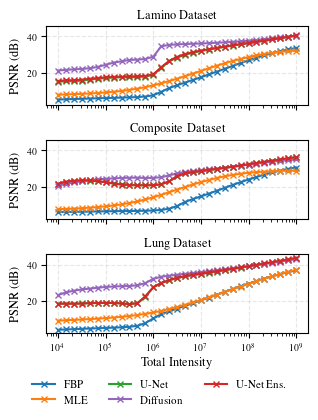

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(ICML_COLUMN_WIDTH, ICML_COLUMN_HEIGHT), sharex=True, sharey=True)
for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
    for model in MODELS:
        plot_metric(ax, dataset, model, metric='psnr', plt_stderr=True, plot_range=False)
    ax.set_ylabel("PSNR (dB)")
    ax.set_title(f"{dataset.capitalize()} Dataset")
    ax.grid(True, which="major", linestyle="--", alpha=0.3)

axes[-1].set_xlabel("Total Intensity")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0), fancybox=False, frameon=False)

fig.subplots_adjust()
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(f"{PLOT_PATH}/psnr_dense.pdf")

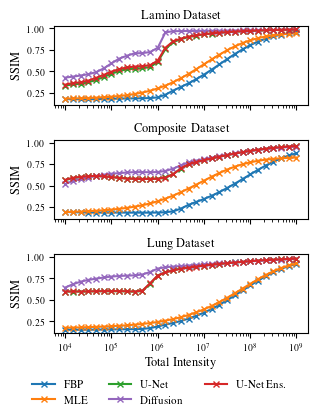

In [7]:
# ssim
fig, axes = plt.subplots(3, 1, figsize=(ICML_COLUMN_WIDTH, ICML_COLUMN_HEIGHT), sharex=True, sharey=True)
for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
    for model in MODELS:
        plot_metric(ax, dataset, model, metric='ssim', plt_stderr=True, plot_range=False)
    ax.set_ylabel("SSIM")
    ax.set_title(f"{dataset.capitalize()} Dataset")

axes[-1].set_xlabel("Total Intensity")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0), fancybox=False, frameon=False)

fig.subplots_adjust()
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(f"{PLOT_PATH}/ssim_dense.pdf")

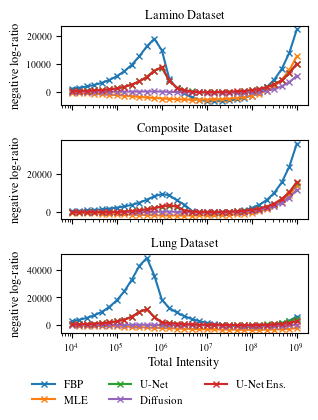

In [8]:
# nll
fig, axes = plt.subplots(3, 1, figsize=(ICML_COLUMN_WIDTH, ICML_COLUMN_HEIGHT), sharex=True)
for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
    for model in MODELS:
        plot_metric(ax, dataset, model, metric='nll_diff', plt_stderr=True, plot_range=False)
    ax.set_ylabel("negative log-ratio")
    ax.set_title(f"{dataset.capitalize()} Dataset")

axes[-1].set_xlabel("Total Intensity")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0), fancybox=False, frameon=False)

fig.subplots_adjust()
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(f"{PLOT_PATH}/nll_dense.pdf")

## Tightness and Coverage Plots

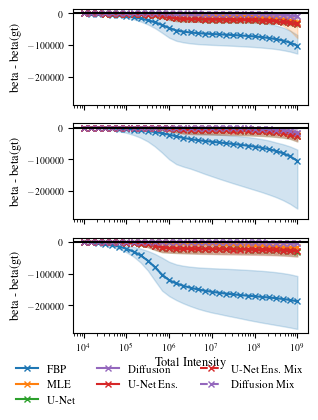

In [9]:
delta = 0.05
# beta diff
fig, axes = plt.subplots(3, 1, figsize=(ICML_COLUMN_WIDTH, ICML_COLUMN_HEIGHT), sharex=True, sharey=True)
for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
    for model in MODELS:
        plot_metric(ax, dataset, model, metric='beta_diff')
    for model in MIXING_MODELS:
        plot_metric(ax, dataset, model, metric='beta_mix_diff')
    ax.set_ylabel("beta - beta(gt)")
    ax.axhline(np.log(1/delta), color='k')
    # ax.set_yscale('log')


axes[-1].set_xlabel("Total Intensity")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0), fancybox=False, frameon=False)

fig.subplots_adjust()
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(f"{PLOT_PATH}/beta_diff_dense.pdf")

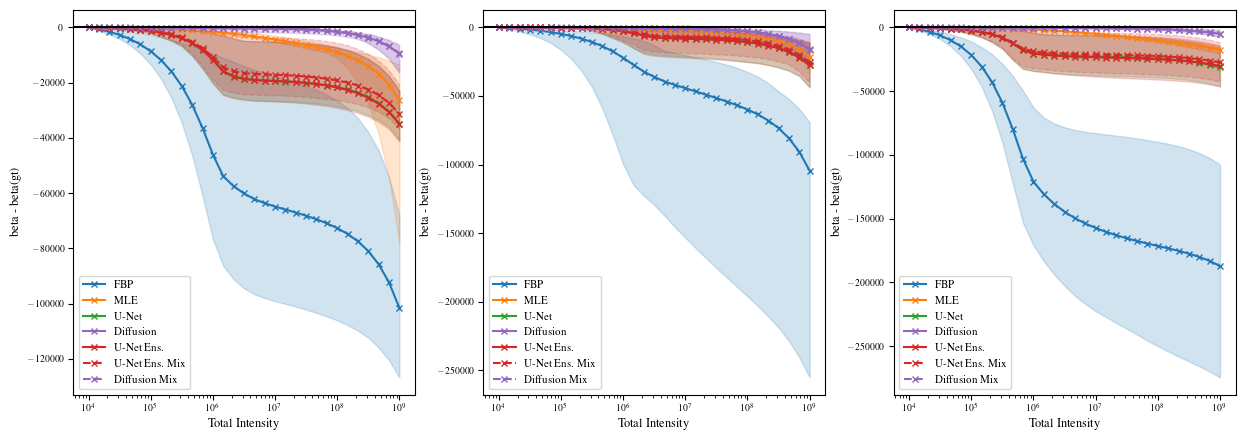

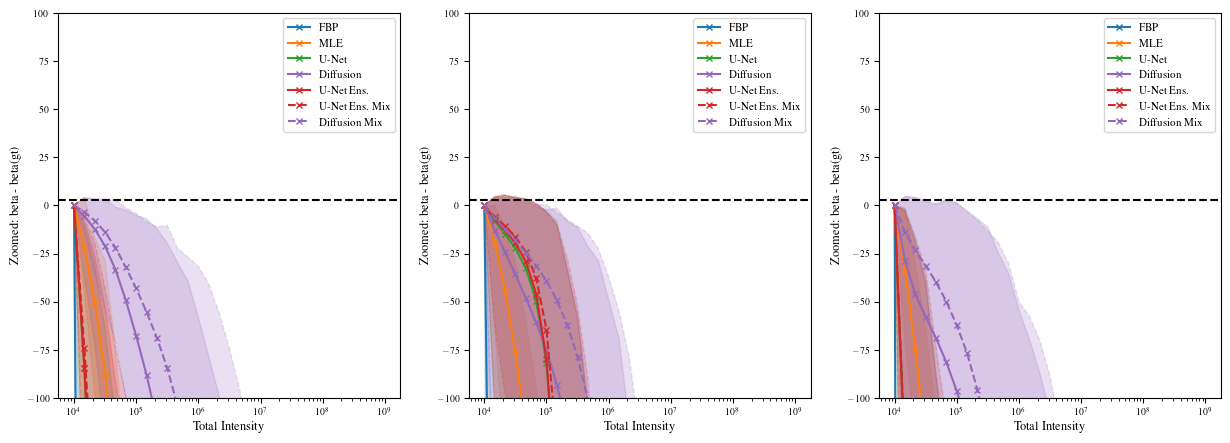

In [10]:
delta = 0.05
# beta diff
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
    for model in MODELS:
        plot_metric(ax, dataset, model, metric='beta_diff')
    for model in MIXING_MODELS:
        plot_metric(ax, dataset, model, metric='beta_mix_diff')
    ax.set_xlabel("Total Intensity")
    ax.set_ylabel("beta - beta(gt)")
    ax.axhline(np.log(1/delta), color='k')
    # ax.set_ylim([0, 100000])
    ax.legend()

# beta zoomed
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
    for model in MODELS:
        plot_metric(ax, dataset, model, metric='beta_diff')
    for model in MIXING_MODELS:
        plot_metric(ax, dataset, model, metric='beta_mix_diff')
    ax.set_xlabel("Total Intensity")
    ax.set_ylabel("Zoomed: beta - beta(gt)")
    ax.set_ylim([-100, 100])
    ax.axhline(np.log(1/delta), color='k', linestyle='--')
    ax.legend()




## NN vs FBP

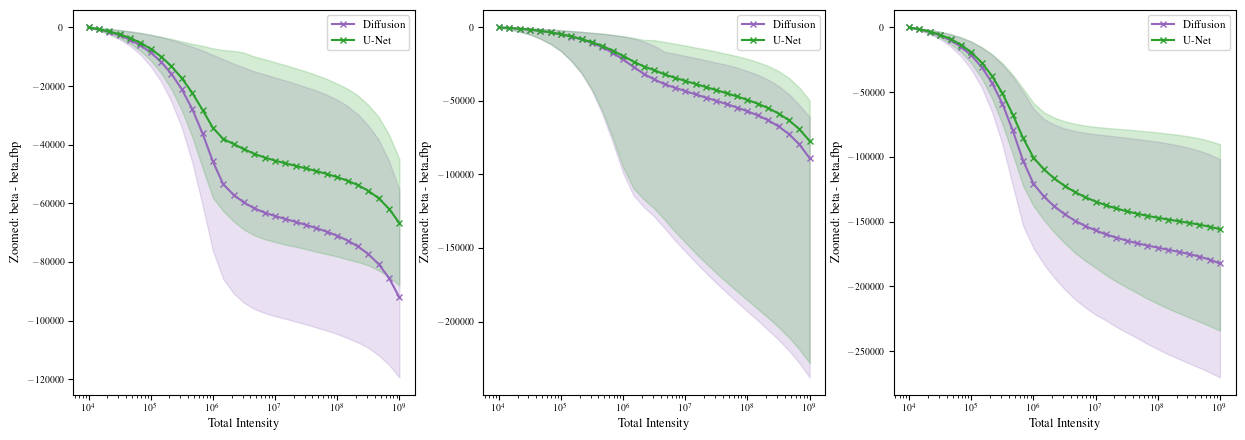

In [11]:
# beta - beta_mix
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
    for model in ['cond_diffusion',  'unet']:
        plot_metric(ax, dataset, model, metric='beta_diff_fbp')
    ax.set_xlabel("Total Intensity")
    ax.set_ylabel("Zoomed: beta - beta_fbp")
    ax.legend()

## Mixing vs Non-mixing

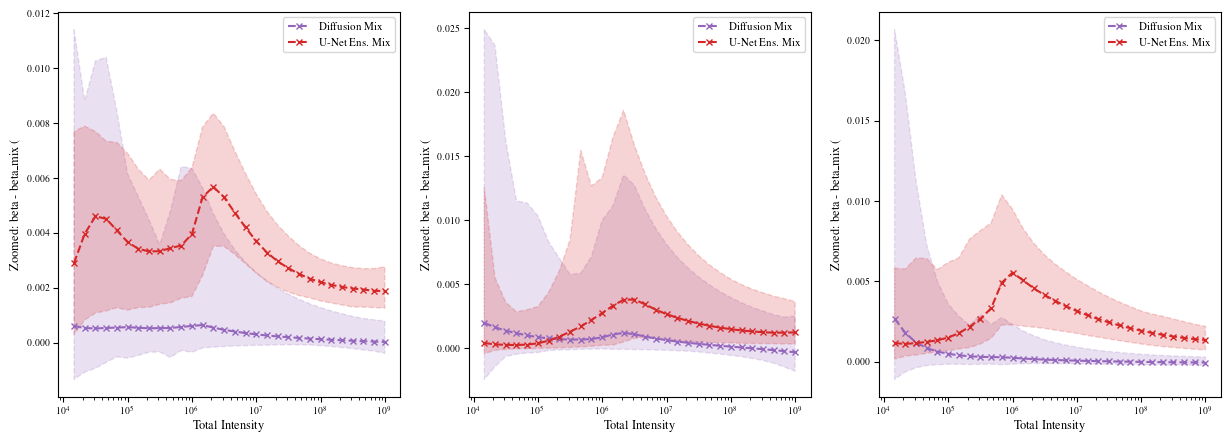

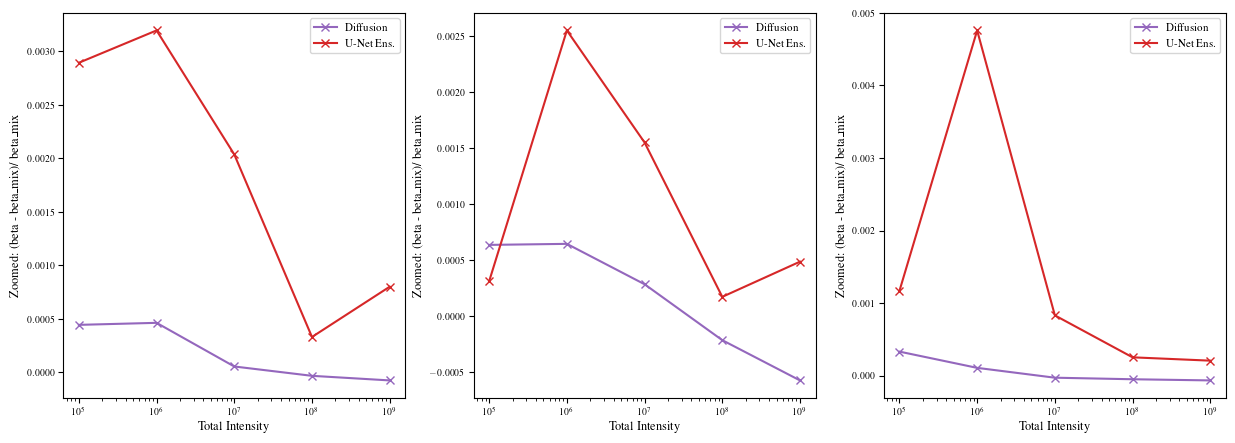

In [12]:
# beta - beta_mix
from matplotlib.pyplot import step


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
    for model in ['cond_diffusion',  'unet_ensemble']:
        plot_metric(ax, dataset, model, metric='beta - beta_mix')
    ax.set_xlabel("Total Intensity")
    ax.set_ylabel("Zoomed: beta - beta_mix (%)")
    ax.legend()



fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    # beta - beta_mix (zoomed)
for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
    for model in ['cond_diffusion', 'unet_ensemble']:
        intensities = []
        values = []
        for initial_intensity, total_intensity in SEGMENTS:
            match_attrs = {'initial_intensity': initial_intensity, 'total_intensity': total_intensity}
            match_attrs.update(MATCH_ATTRS.get(model, {}))
            ds = find_experiment(attrs_segments, datasets_segments, dataset, model, aggregate_seeds=True, match_attrs=match_attrs)[0]
            y = (ds['beta'] - ds['beta_mix'])/ ds['beta_mix']

            y = y.sel(step=10).mean(dim=['index', 'seed']).squeeze().values # in percent
            intensities.append(total_intensity)
            values.append(y)
        ax.plot(intensities, values, marker='x', **LINE_KWARGS[model])
        ax.set_xlabel("Total Intensity")
        ax.set_ylabel(f"Zoomed: (beta - beta_mix)/ beta_mix")
        ax.set_xscale("log")
        # ax.set_ylim([-0.01, 0.01])
        ax.legend()
# # beta - beta_mix (zoomed)
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
#     for model in ['cond_diffusion', 'diffusion', 'unet_ensemble']:
#         plot_psnr(ax, dataset, model, metric='beta - beta_mix')
#     ax.set_xlabel("Total Intensity")
#     ax.set_ylabel("Zoomed: beta - beta_mix (%)")
#     ax.legend()
#     ax.set_ylim([-0.01, 0.01])



# # beta diff fbp
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
#     for model in models:
#         plot_psnr(ax, dataset, model, metric='beta_diff_fbp')
#     ax.set_xlabel("Total Intensity")
#     ax.set_ylabel("beta - beta(fbp)")
#     ax.legend()


## Coverage, width and baseline comparison

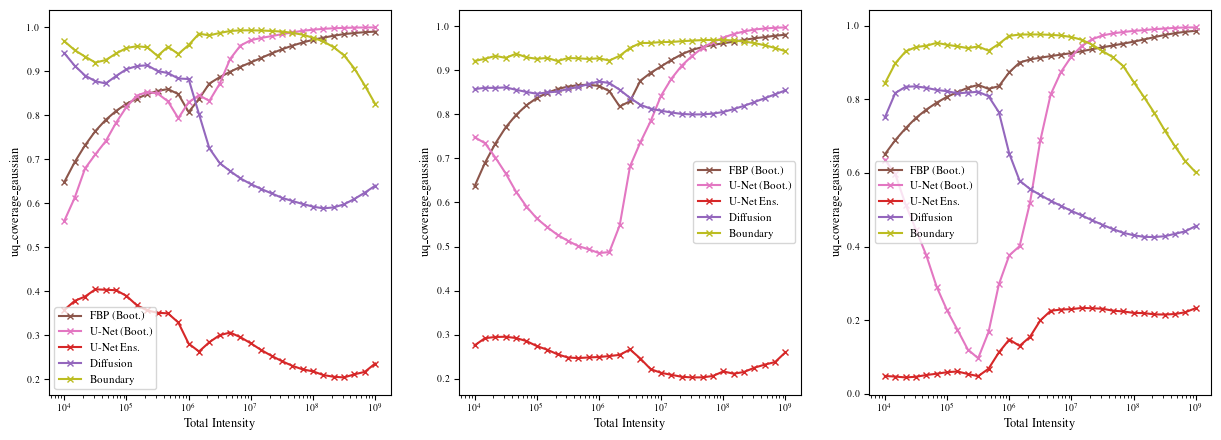

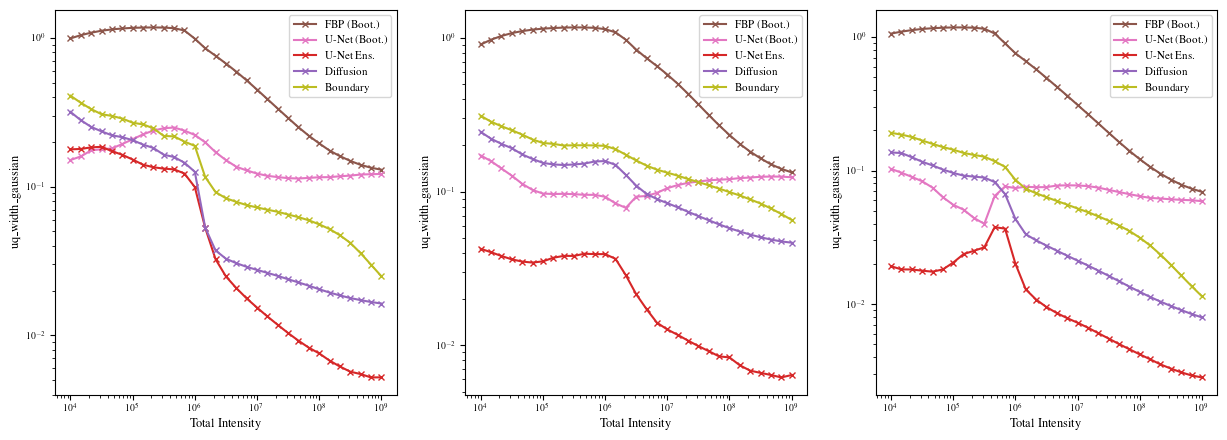

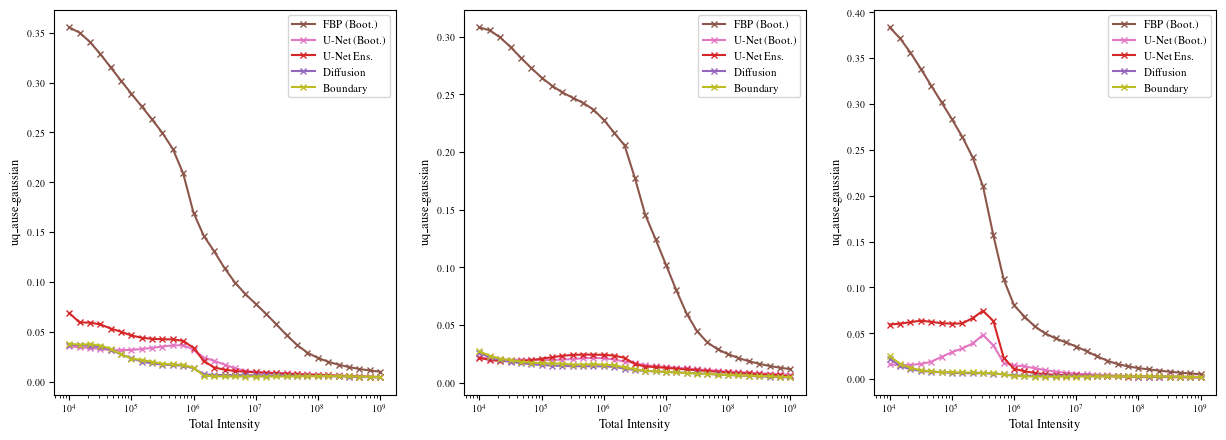

In [13]:
# uq_coverage_gaussian_0.05

for uq_metric in [
    'uq_coverage', 
    # 'uq_simultaneous_coverage', 
    # 'uq_error_correlation',
    'uq_width',
    'uq_ause'
    # 'uq_coverage_basic_0.05', 
    # 'uq_error_correlation_basic_0.05'
    ]:
    for ci_name in [
        'gaussian', 
        # 'gaussian_conservative_ci', 
        # 'simultaneous_ci'
        ]:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
            for model in ['fbp_bootstrap', 'unet_bootstrap', 'unet_ensemble', 'cond_diffusion', 'diverse_cond_diffusion']:
                plot_metric(ax, dataset, model, metric=f"{uq_metric}_{ci_name}_0.05", plot_range=False)
            ax.set_xlabel("Total Intensity")
            ax.set_ylabel(f"{uq_metric}_{ci_name}")
            ax.legend()
            if uq_metric == 'uq_width':
                ax.set_yscale('log')
        plt.show()

## Rotation Crossover Plots

<xarray.DataArray 'beta' (rotation: 11)> Size: 88B
array([0.   , 0.   , 0.   , 0.646, 0.874, 0.97 , 1.   , 1.   , 1.   ,
       1.   , 1.   ])
Coordinates:
  * rotation  (rotation) float32 44B 0.0 0.1 0.2129 0.4534 ... 19.85 42.27 90.0
    step      int32 4B 10
    dataset   <U4 16B 'lung'

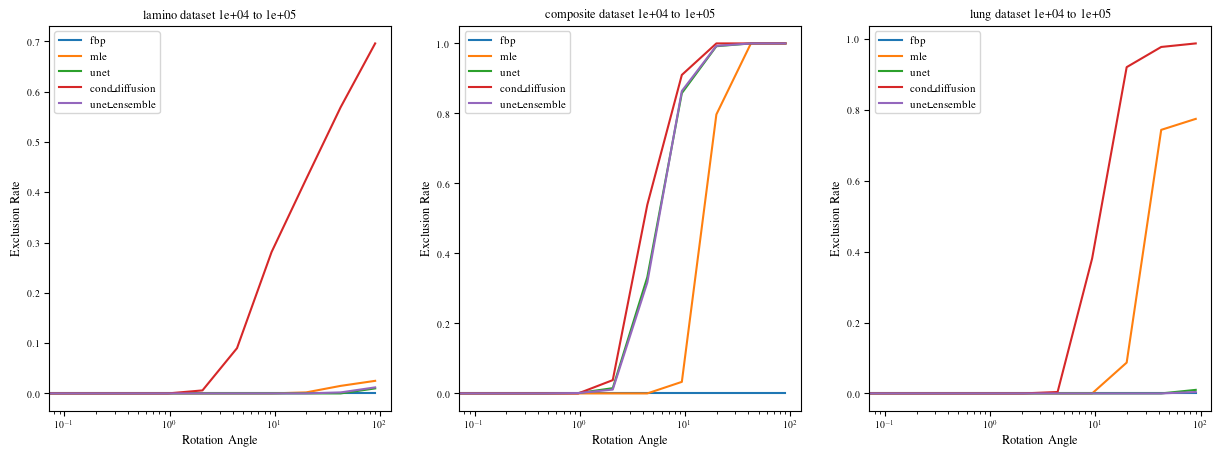

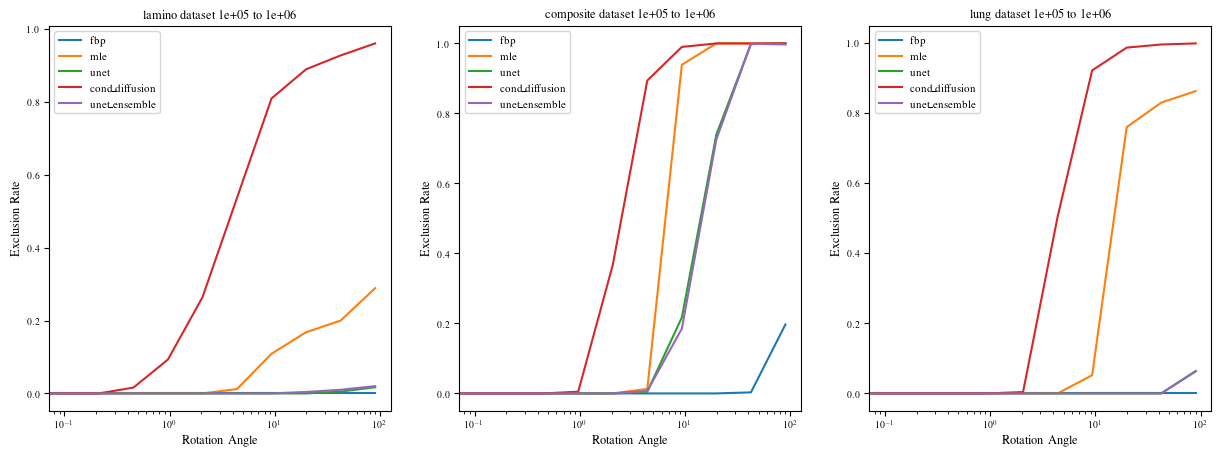

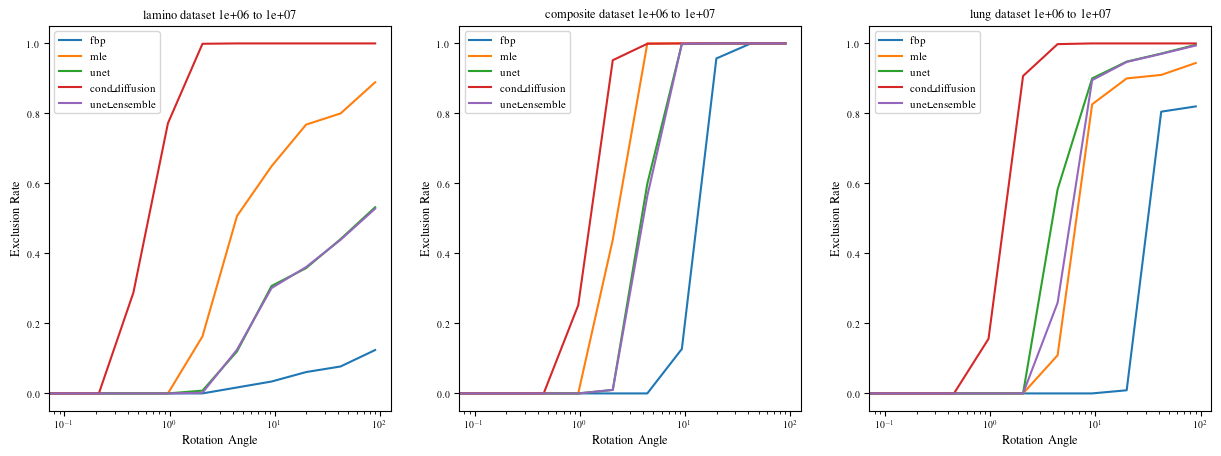

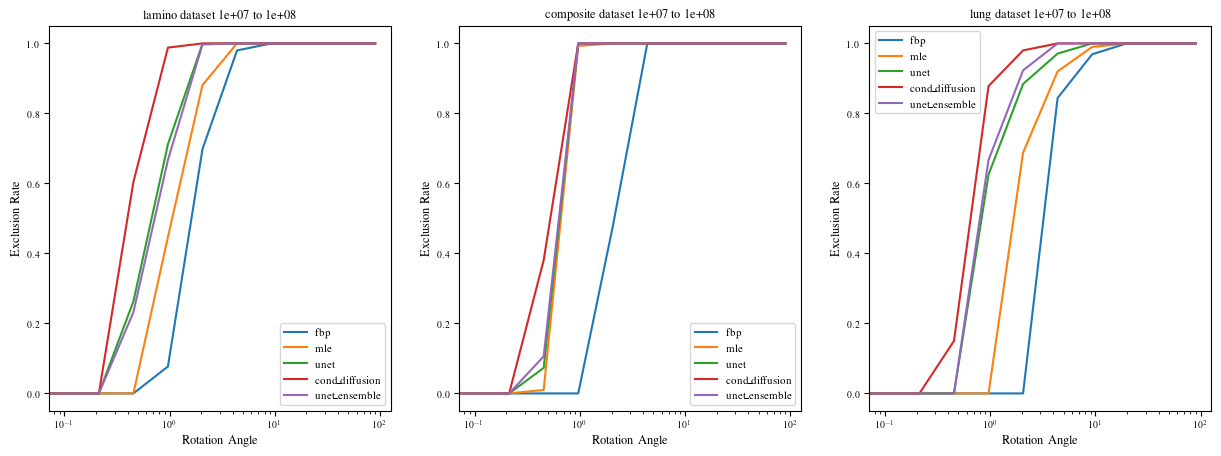

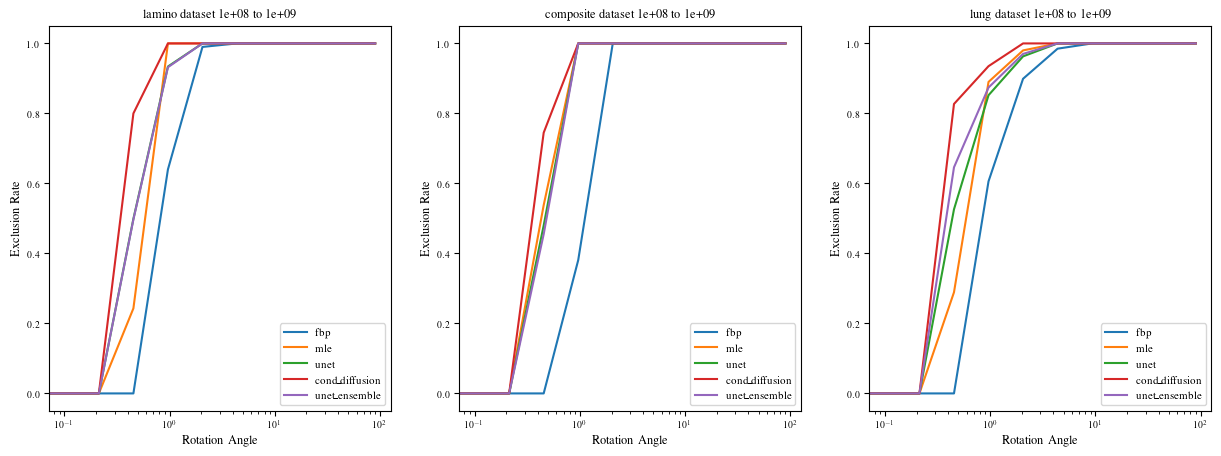

In [15]:
rotation = find_experiment(attrs, datasets, 'lamino', 'gt', samples=True)[0]['rotation'].values
# beta diff with rotation 1.0


for initial_intensity, total_intensity in SEGMENTS:
    gt_rotation = rotation[3]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
        ds_gt = find_experiment(attrs_segments, datasets_segments, dataset, 'gt', samples=True, match_attrs={'initial_intensity': initial_intensity, 'total_intensity': total_intensity})[0]
        for model in MODELS:
            matching_attrs = {'initial_intensity': initial_intensity, 'total_intensity': total_intensity}
            matching_attrs.update(MATCH_ATTRS.get(model, {}))
            ds = find_experiment(attrs_segments, datasets_segments, dataset, model, match_attrs=matching_attrs, aggregate_seeds=True)[0]
            beta_diff = ds_gt.sel(step=10)['beta'] - ds.sel(step=10)['beta']
            exclusion = beta_diff > np.log(1/delta)
            exclusion = exclusion.mean(dim=['index', 'seed']).squeeze()
            ax.plot(ds_gt.rotation, exclusion, label=model)
        ax.set_xscale('log')
        ax.set_title(f"{dataset} dataset {initial_intensity:.0e} to {total_intensity:.0e}")
        ax.legend()
        ax.set_ylabel("Exclusion Rate")
        ax.set_xlabel("Rotation Angle")
        # ax.set_xlabel("Total Intensity")
        # ax.set_ylabel(f"beta - beta(gt_rot{gt_rotation})")
        # ax.legend()
# ds_gt
exclusion

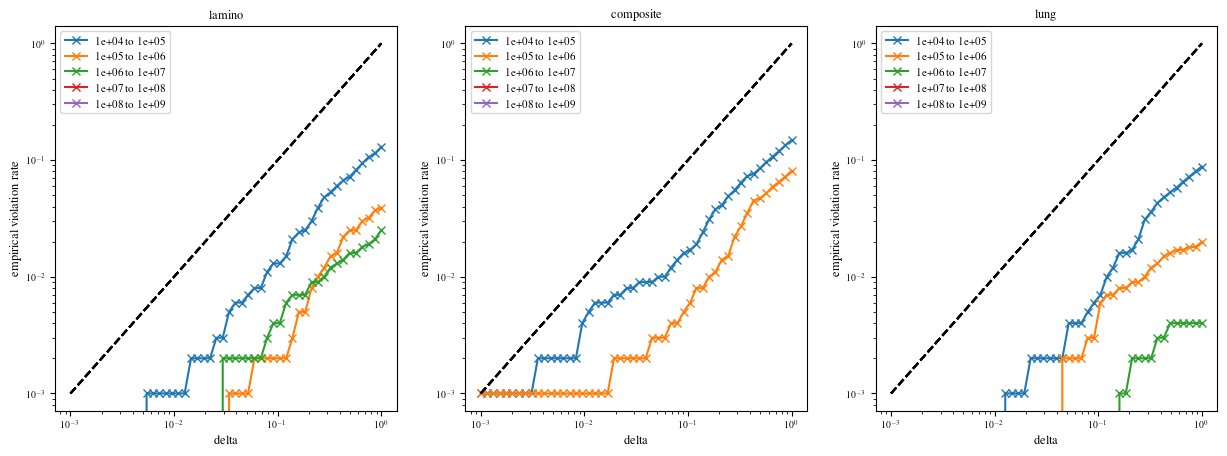

In [16]:

model = 'cond_diffusion'
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for inital_intensity, total_intensity in SEGMENTS:

    for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
        matching_attrs = {'initial_intensity': inital_intensity, 'total_intensity': total_intensity}
        ds_gt = find_experiment(attrs_segments, datasets_segments, dataset, 'gt', samples=False, match_attrs=matching_attrs)[0]
        matching_attrs.update(MATCH_ATTRS.get(model, {}))
        ds_beta = find_experiment(attrs_segments, datasets_segments, dataset, model, samples=False, aggregate_seeds=True, match_attrs=matching_attrs)[0]


        deltas = np.linspace(0.001, 1, 10)
        deltas = np.logspace(-3, 0)
        coverages = []
        for delta in deltas:
            coverage = (((ds_gt['beta'] - ds_beta['beta_mix']).sel(step=slice(1, None))).max(dim='step') >= 1 * np.log(1./delta)).mean(dim=('dataset', 'index', 'seed'))
            # break
            coverages.append(coverage)
        ax.plot(deltas, coverages, marker='x', label=f"{inital_intensity:.0e} to {total_intensity:.0e}")
        ax.plot(deltas, deltas, color='k', linestyle='--')
        ax.set_xlabel('delta')
        ax.set_ylabel('empirical violation rate')
        ax.set_title(f"{dataset}")
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.legend()
    # fig.suptitle(f"{inital_intensity:.0e} to {total_intensity:.0e}", fontsize=11)

# (ds_gt['beta'] - ds_beta['beta_mix']).max(dim=('dataset', 'index', 'seed')).plot()
# plt.axhline(np.log(1/delta), color='k', linestyle='--')

## Hallucination plots

<xarray.DataArray 'psnr' (step: 31)> Size: 124B
array([21.804104, 22.44505 , 23.16803 , 23.901766, 24.52238 , 25.186909,
       25.840673, 26.447073, 26.91538 , 27.40576 , 27.92996 , 28.397572,
       28.797726, 29.17512 , 29.517624, 29.820934, 30.295076, 30.674675,
       31.171928, 31.90463 , 32.662136, 33.604626, 34.391056, 34.995754,
       35.629875, 35.348026, 35.83795 ,       nan,       nan,       nan,
             nan], dtype=float32)
Coordinates:
  * step     (step) int32 124B 0 1 2 3 4 5 6 7 8 ... 22 23 24 25 26 27 28 29 30
    model    <U9 36B 'diffusion'
    dataset  <U4 16B 'lung'

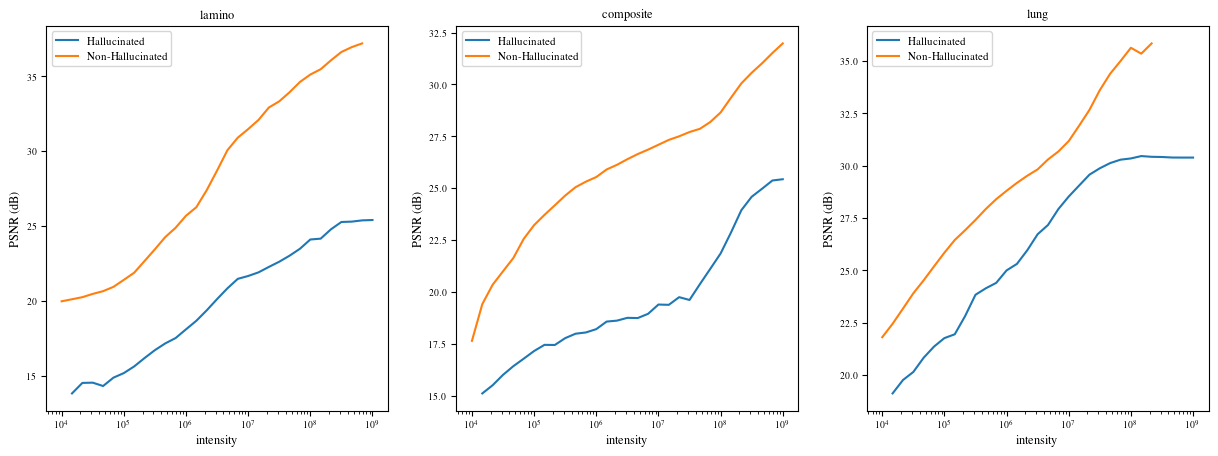

In [19]:

# ds_samples['hallucination'] = ds_samples['nll_1'] > ds['beta_mix'] + np.log(1/0.05)
# # print(ds_samples['hallucination'].sum(('dataset', 'index', 'sample', 'seed')))

# # compute mean psnr for samples where hallucination is False
# ds_samples_no_hallucination = ds_samples.where(ds_samples['hallucination'] == False, drop=False)
# # print(ds_samples_no_hallucination['psnr'].mean(('dataset', 'index', 'sample', 'seed')))

# # compute mean psnr for samples where hallucination is True
# ds_samples_hallucination = ds_samples.where(ds_samples['hallucination'] == True, drop=False)
# # print(ds_samples_hallucination['psnr'].mean(('dataset', 'index', 'sample', 'seed')))

# psnr_hallucinated = ds_samples_hallucination['psnr'].mean(('index', 'sample', 'seed'))
# psnr_non_hallucinated = ds_samples_no_hallucination['psnr'].mean(('index', 'sample', 'seed'))


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
    ds = find_experiment(attrs, datasets, dataset, 'cond_diffusion', samples=False, aggregate_seeds=True, match_attrs=MATCH_ATTRS['cond_diffusion'])[0]
    # total_intensity = ds['intensity'].sum(dim='step').mean(dim=['index', 'seed']).squeeze()
    ds_samples = find_experiment(attrs, datasets, dataset, 'diffusion', samples=True, aggregate_seeds=True, match_attrs={'guidance_num_gradient_steps': 5, 'guidance_lr': 1e-1})[0].copy()
    # ds_samples = find_experiment(attrs, datasets, dataset, 'cond_diffusion', samples=True, aggregate_seeds=True)[0].copy()
    ds_samples['hallucination'] = ds_samples['nll_1'] > ds['beta_mix'] + np.log(1/0.05)
    psnr_hallucinated = ds_samples.where(ds_samples['hallucination'] == True, drop=False)['psnr'].mean(('index', 'sample', 'seed')).squeeze()
    psnr_non_hallucinated = ds_samples.where(ds_samples['hallucination'] == False, drop=False)['psnr'].mean(('index', 'sample', 'seed')).squeeze()
    # break
    intensity = ds.sel(seed=0, index=0)['intensity']
    x = intensity.cumsum()
    ax.plot(x, psnr_hallucinated, label='Hallucinated')
    ax.plot(x, psnr_non_hallucinated, label='Non-Hallucinated')
    ax.set_title(f"{dataset}")
    ax.set_xlabel("intensity")
    ax.set_ylabel("PSNR (dB)")
    ax.set_xscale("log")
    ax.legend()
psnr_non_hallucinated

## Diffusion Ablation

In [29]:
ablation_datasets, ablation_attrs = load_runs_dense("../results-final/diffusion-ablation/", "../results-final/2026-01-24/")
print_stats(ablation_attrs)

1e+04 to 1e+09: 258 experiments


dataset,composite,lamino,lung
model,,,
cond_diffusion,60,60,60
diffusion,12,12,12
diverse_cond_diffusion,6,6,6
fbp,1,1,1
fbp_bootstrap,1,1,1
gt,2,2,2
mle,1,1,1
unet,1,1,1
unet_bootstrap,1,1,1


In [30]:
ablation_attrs['output_dir']

experiment_id
067d7a56            results-final/diffusion-ablation
067d7a56_samples    results-final/diffusion-ablation
191f3543            results-final/diffusion-ablation
191f3543_samples    results-final/diffusion-ablation
1a2821f7            results-final/diffusion-ablation
                                  ...               
f4f5421a_samples            results-final/2026-01-24
f5d09fad                    results-final/2026-01-24
f5d09fad_samples            results-final/2026-01-24
f9ee048b                    results-final/2026-01-24
ffaa0fe5                    results-final/2026-01-24
Name: output_dir, Length: 258, dtype: str

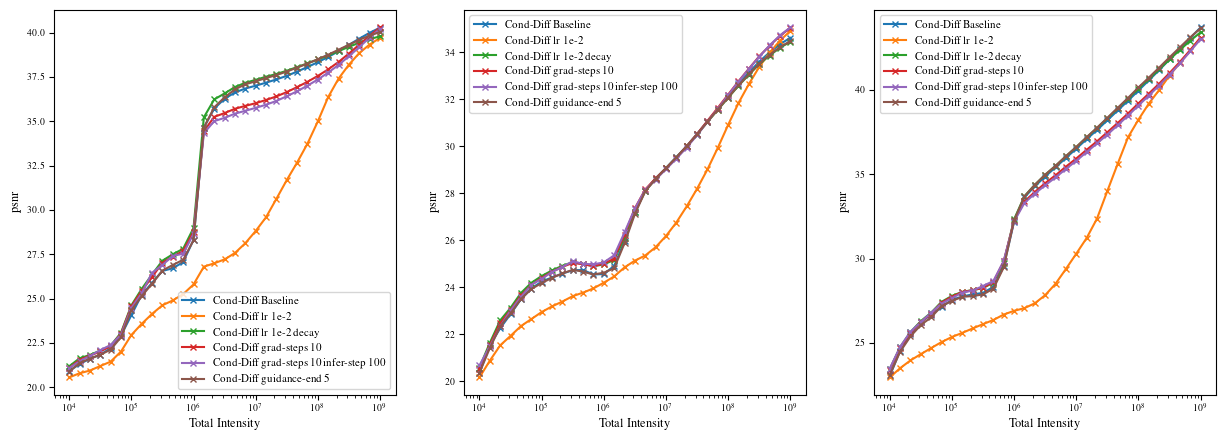

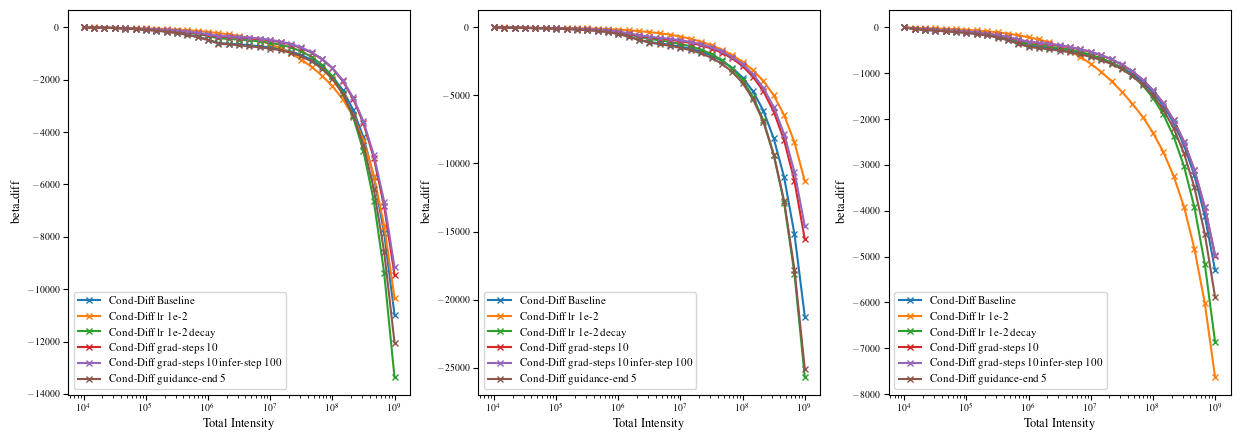

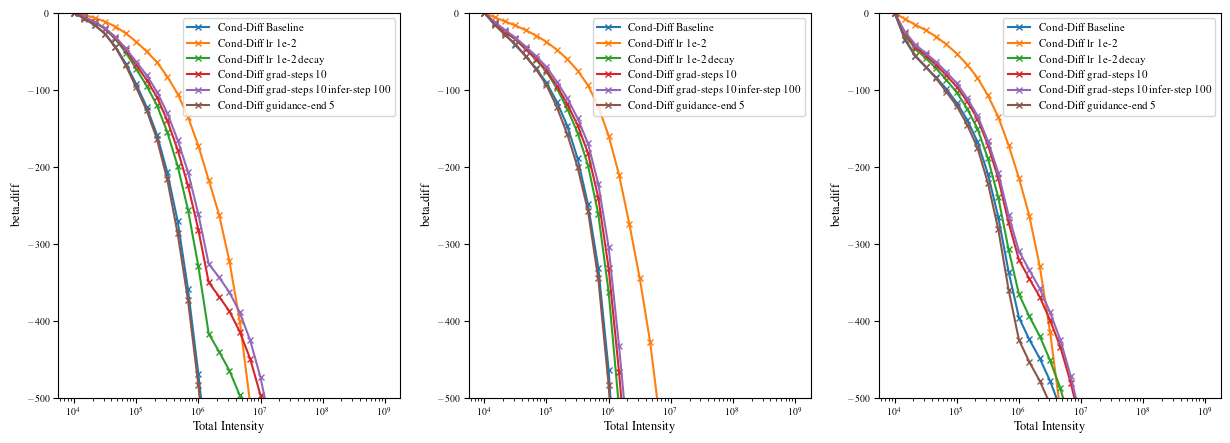

In [33]:
# psnr
for metric in ['psnr', 'beta_diff', 'beta_diff_zoomed']:
    zoomed = metric.endswith('zoomed')
    if zoomed:
        metric = 'beta_diff'
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, dataset in zip(axes, ['lamino', 'composite', 'lung']):
        plot_metric(ax, dataset, 'cond_diffusion', metric=metric, _attrs=ablation_attrs, _datasets=ablation_datasets, plot_range=False,
                line_kwargs={'label': 'Cond-Diff Baseline', 'color': 'C0'}, 
                match_attrs={'guidance_lr' : 1e-3, 'guidance_num_gradient_steps' : 5, 'diffusion_num_inference_steps' : 50, 'guidance_lr_decay' : False, 'guidance_end' : 0})
        plot_metric(ax, dataset, 'cond_diffusion', metric=metric, _attrs=ablation_attrs, _datasets=ablation_datasets, plot_range=False,
                line_kwargs={'label': 'Cond-Diff lr 1e-2', 'color': 'C1'}, 
                match_attrs={'guidance_lr' : 1e-2, 'guidance_num_gradient_steps' : 5, 'diffusion_num_inference_steps' : 50, 'guidance_lr_decay' : False, 'guidance_end' : 0})
        plot_metric(ax, dataset, 'cond_diffusion', metric=metric, _attrs=ablation_attrs, _datasets=ablation_datasets, plot_range=False,
                line_kwargs={'label': 'Cond-Diff lr 1e-2 decay', 'color': 'C2'}, 
                match_attrs={'guidance_lr' : 1e-2, 'guidance_num_gradient_steps' : 5, 'diffusion_num_inference_steps' : 50, 'guidance_lr_decay' : True, 'guidance_end' : 0})
        plot_metric(ax, dataset, 'cond_diffusion', metric=metric, _attrs=ablation_attrs, _datasets=ablation_datasets, plot_range=False,
                line_kwargs={'label': 'Cond-Diff grad-steps 10', 'color': 'C3'}, 
                match_attrs={'guidance_lr' : 1e-3, 'guidance_num_gradient_steps' : 10, 'diffusion_num_inference_steps' : 50, 
                             'guidance_lr_decay' : False, 'guidance_end' : 0, 'output_dir': 'results-final/diffusion-ablation'})
        plot_metric(ax, dataset, 'cond_diffusion', metric=metric, _attrs=ablation_attrs, _datasets=ablation_datasets, plot_range=False,
                line_kwargs={'label': 'Cond-Diff grad-steps 10 infer-step 100', 'color': 'C4'}, 
                match_attrs={'guidance_lr' : 1e-3, 'guidance_num_gradient_steps' : 10, 'diffusion_num_inference_steps' : 100, 'guidance_lr_decay' : False, 'guidance_end' : 0})
        plot_metric(ax, dataset, 'cond_diffusion', metric=metric, _attrs=ablation_attrs, _datasets=ablation_datasets, plot_range=False,
                line_kwargs={'label': 'Cond-Diff guidance-end 5', 'color': 'C5'}, 
                match_attrs={'guidance_lr' : 1e-3, 'guidance_num_gradient_steps' : 5, 'diffusion_num_inference_steps' : 50, 'guidance_lr_decay' : False, 'guidance_end' : 5})
        ax.set_xlabel("Total Intensity")
        ax.set_ylabel(metric)
        ax.legend()

        if zoomed:
            ax.set_ylim([-500, 0])